In [14]:
import os
import sys
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
def get_weighted_stats(group_df, val_col="latency", weight_col="count", label="") -> dict:
    """
    Calculates weighted boxplot statistics (min, q1, median, q3, max)
    Assumes group_df is already sorted by val_col if not done previously.

    @returns Dictionary of percentiles
    """
    d = group_df.sort_values(val_col)
    data = d[val_col]
    weights = d[weight_col]

    cumsum = weights.cumsum()
    cutoff = cumsum / cumsum.iloc[-1]

    # function to find value at specific percentile
    def get_quantile(q):
        # searchsorted finds the index where the cumulative weight passes the quantile
        idx = np.searchsorted(cutoff, q)
        return data.iloc[idx]

    ret = {
        "med": get_quantile(0.5),
        "q1": get_quantile(0.25),
        "q3": get_quantile(0.75),
        "whislo": data.min(),  # 0th percentile
        "whishi": get_quantile(0.99)   # 100th percentile
        # "whishi": data.max()   # 100th percentile
    }

    if label != "":
        ret["label"] = label

    return ret


In [16]:
services = ["redis", "valkey", "keydb", "acdis"]
#services = ["redis", "valkey", "keydb"]
cluster_sizes = [1,3,4,5]
cluster_percentiles = { size: {} for size in cluster_sizes}
# Save the median latencies of SET,GET,DEL for sizes 1,3,4,5
cmd_latencies = { service: [] for service in services}

# Create output directories
for i in cluster_sizes:
    d = f"images/{i}-nodes/"
    if not os.path.isdir(d):
        os.makedirs(d)

In [17]:
all_folders = {
    1: ["single-node/redis", "single-node/valkey", "single-node/keydb", "single-node/acdis"],
    3: ["three-nodes/redis", "three-nodes/valkey", "three-nodes/keydb", "three-nodes/acdis"],
    4: ["four-nodes/redis", "four-nodes/valkey", "four-nodes/keydb", "four-nodes/acdis"],
    5: ["five-nodes/redis", "five-nodes/valkey", "five-nodes/keydb", "five-nodes/acdis"]
}

#all_folders = {
#    1: ["single-node/redis", "single-node/valkey", "single-node/keydb"],
#    3: ["three-nodes/redis", "three-nodes/valkey", "three-nodes/keydb"],
#    4: ["four-nodes/redis", "four-nodes/valkey", "four-nodes/keydb"],
#    5: ["five-nodes/redis", "five-nodes/valkey", "five-nodes/keydb"]
#}

220    584812
221    568398
222    548179
223    531962
224    514786
        ...  
280      5669
281      5388
282      4908
283      4729
284      4490
Name: count, Length: 65, dtype: int64

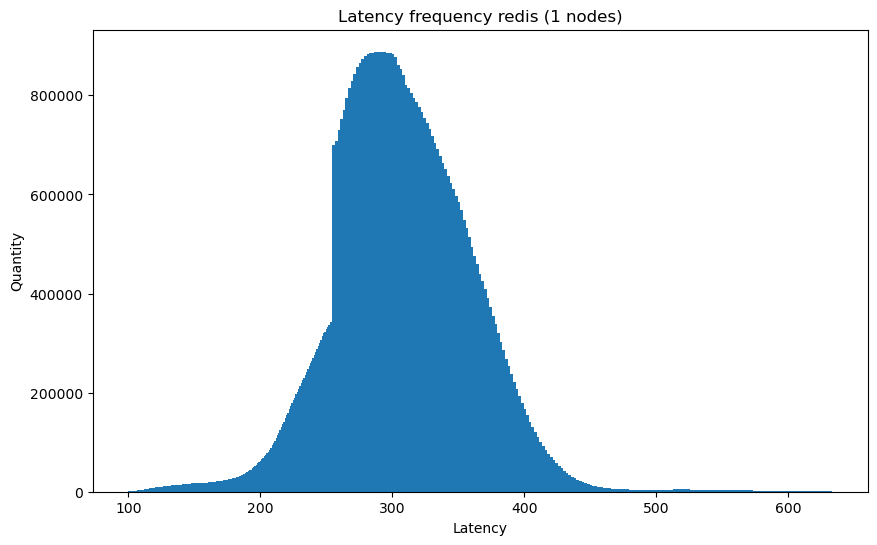

redis DEL: 299  μs
redis GET: 297  μs
redis SET: 301  μs


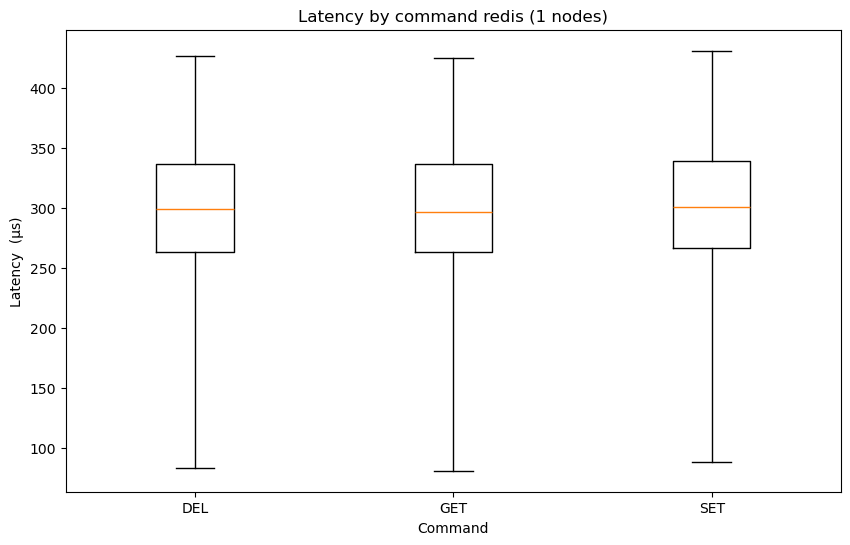

221    649776
222    726109
223    804573
224    880898
225    958677
        ...  
281     26507
282     23755
283     21350
284     19334
285     17459
Name: count, Length: 65, dtype: int64

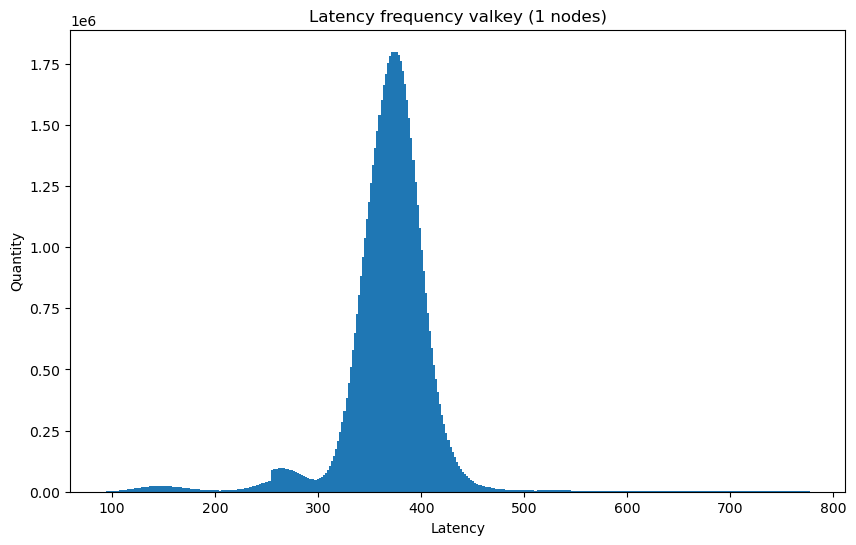

valkey DEL: 371  μs
valkey GET: 371  μs
valkey SET: 373  μs


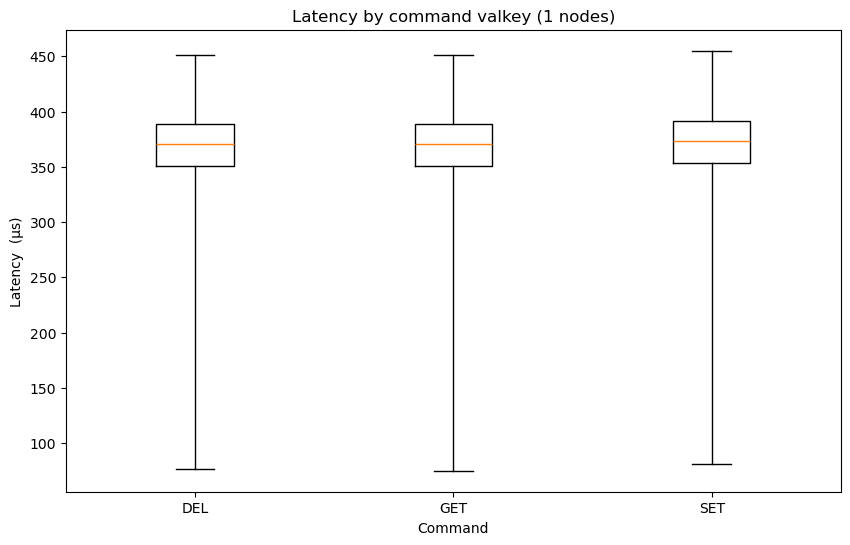

214    2384724
215    2381913
216    2341355
217    2265418
218    2161160
        ...   
274       9379
275       9052
276       8727
277       8401
278       8213
Name: count, Length: 65, dtype: int64

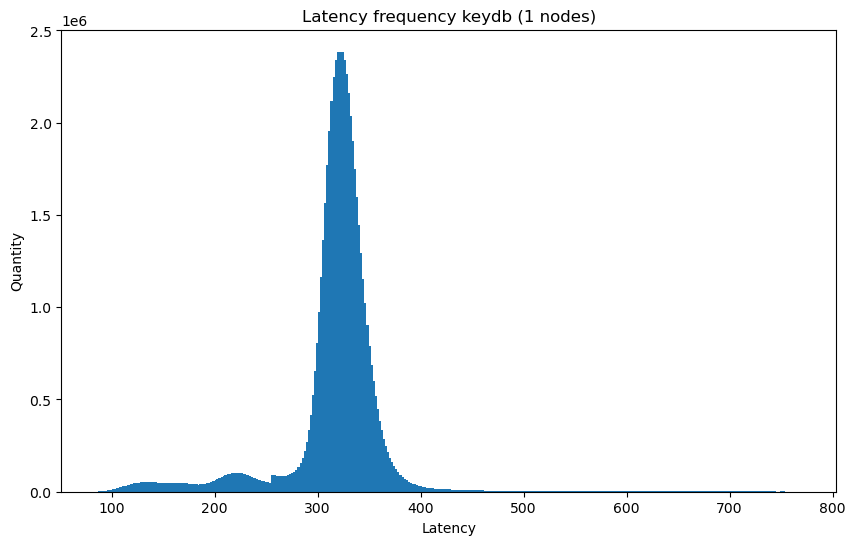

keydb DEL: 321  μs
keydb GET: 321  μs
keydb SET: 323  μs


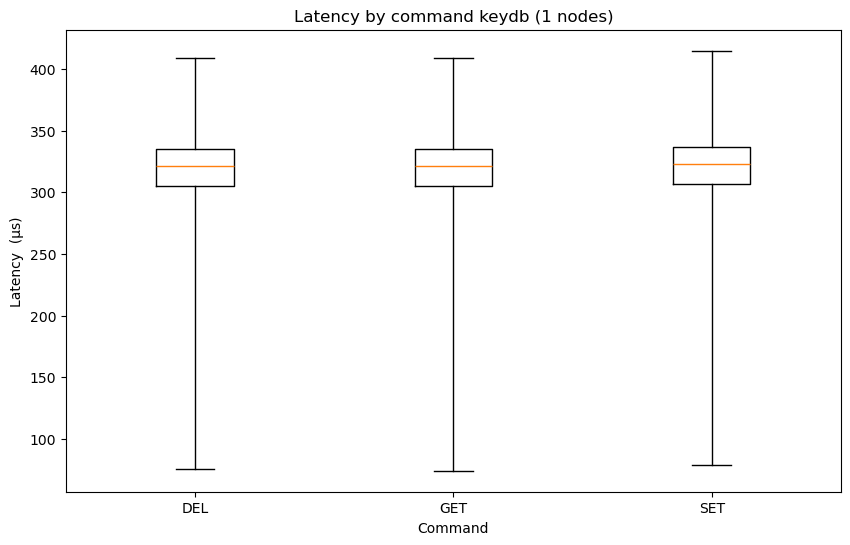

217    1845
218    1802
219    1845
220    1797
221    1735
       ... 
277    1315
278    1302
279    1286
280    1276
281    1208
Name: count, Length: 65, dtype: int64

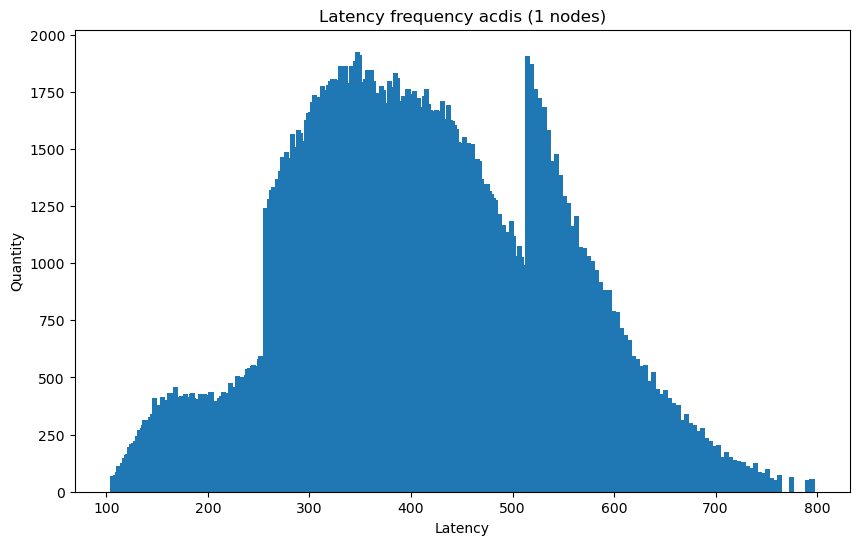

acdis DEL: 371  μs
acdis GET: 369  μs
acdis SET: 375  μs


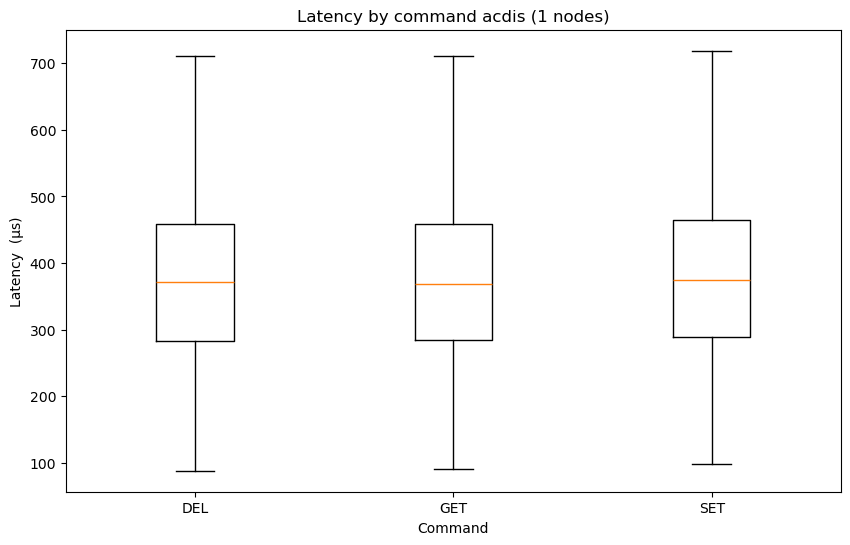

212    7381
213    7056
214    6562
215    6386
216    5883
217    5552
218    5369
219    4943
220    4680
221    4482
222    4217
223    3993
224    3837
225    3649
226    3265
227    3280
228    3114
229    2907
230    2789
231    2694
232    2616
233    2349
234    2379
235    2217
236    1973
237    2100
238    1898
239    1833
240    1744
241    1719
242    1716
243    1563
244    1541
245    1439
246    1411
247    1340
248    1350
249    1297
250    1221
251    1143
252    1181
253    1138
254    1126
255    1010
Name: count, dtype: int64

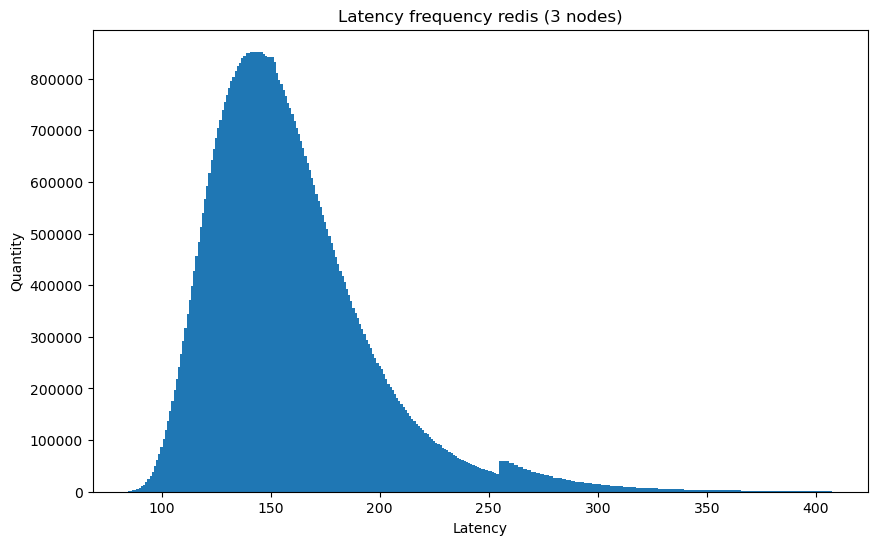

redis DEL: 153  μs
redis GET: 152  μs
redis SET: 158  μs


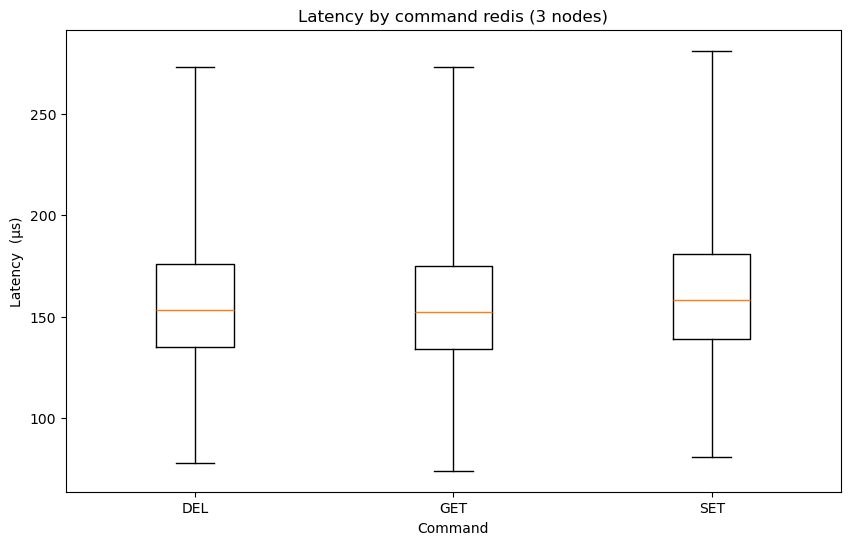

207    44484
208    41955
209    39214
210    37049
211    34924
       ...  
267     1469
268     1309
269     1406
270     1285
271     1252
Name: count, Length: 65, dtype: int64

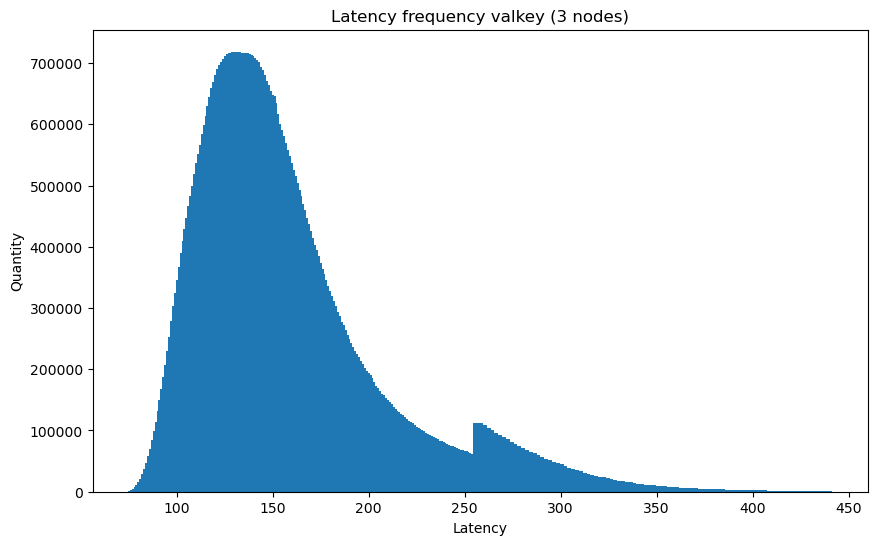

valkey DEL: 146  μs
valkey GET: 145  μs
valkey SET: 150  μs


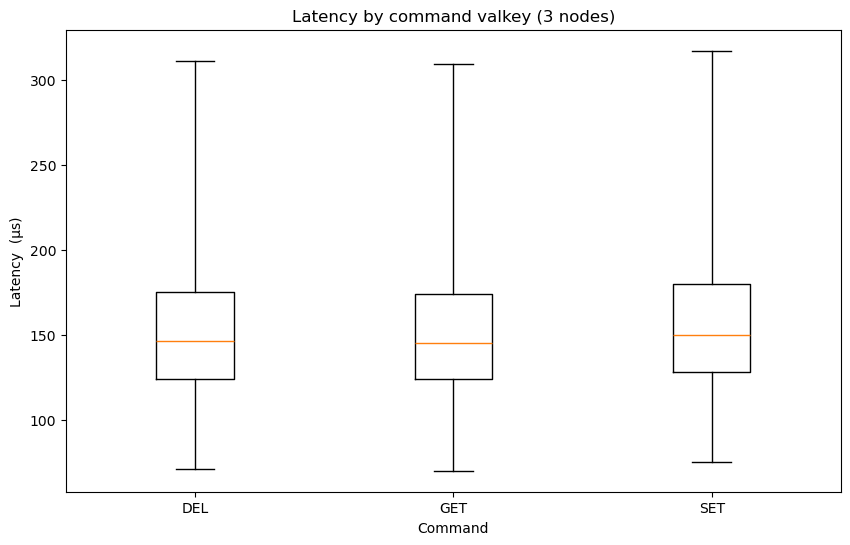

207    4336
208    4219
209    4017
210    3886
211    3838
212    3680
213    3555
214    3345
215    3278
216    3200
217    3105
218    3101
219    2793
220    2807
221    2679
222    2690
223    2507
224    2496
225    2330
226    2295
227    2260
228    2162
229    2106
230    2019
231    1950
232    1828
233    1909
234    1761
235    1762
236    1693
237    1776
238    1638
239    1543
240    1498
241    1454
242    1398
243    1375
244    1391
245    1247
246    1277
247    1193
248    1183
249    1158
250    1142
251    1135
252    1030
253    1039
255    1016
Name: count, dtype: int64

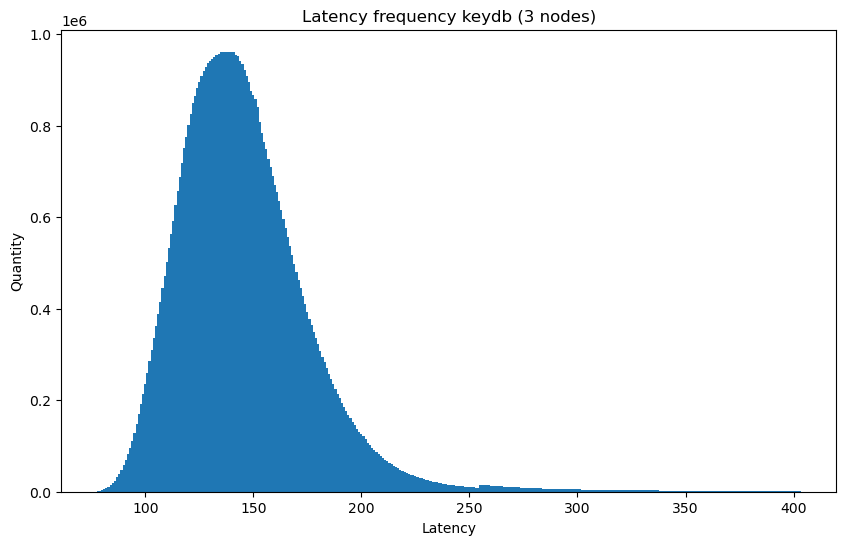

keydb DEL: 142  μs
keydb GET: 141  μs
keydb SET: 148  μs


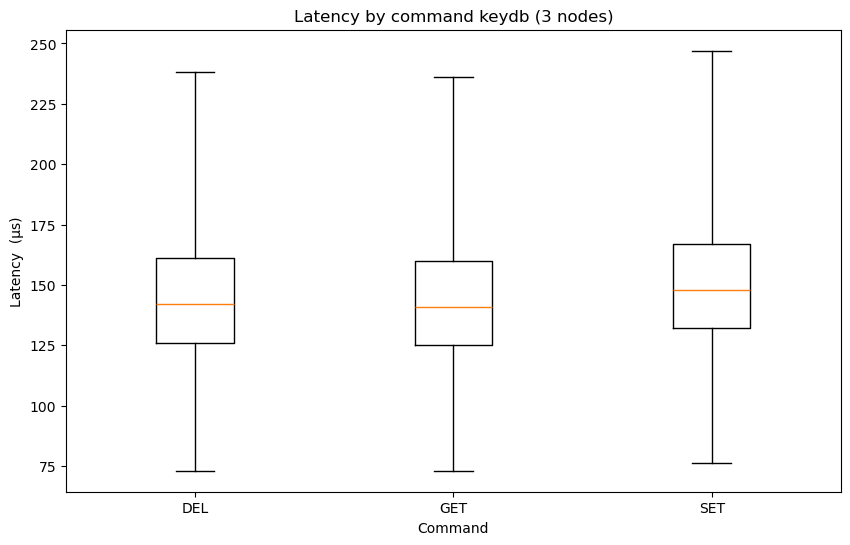

247    100
248    110
249    105
250    111
251    106
      ... 
307    188
308    161
309    159
310    192
311    163
Name: count, Length: 65, dtype: int64

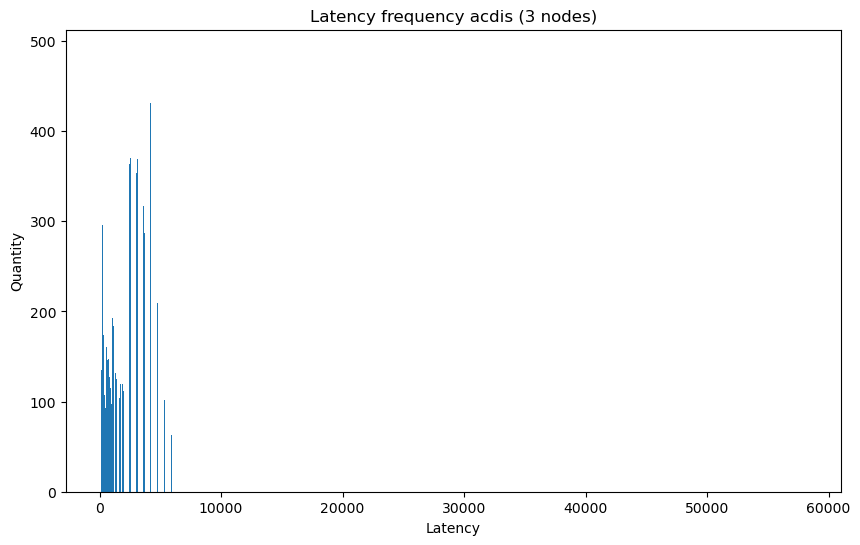

acdis DEL: 1831  μs
acdis GET: 1247  μs
acdis SET: 1295  μs


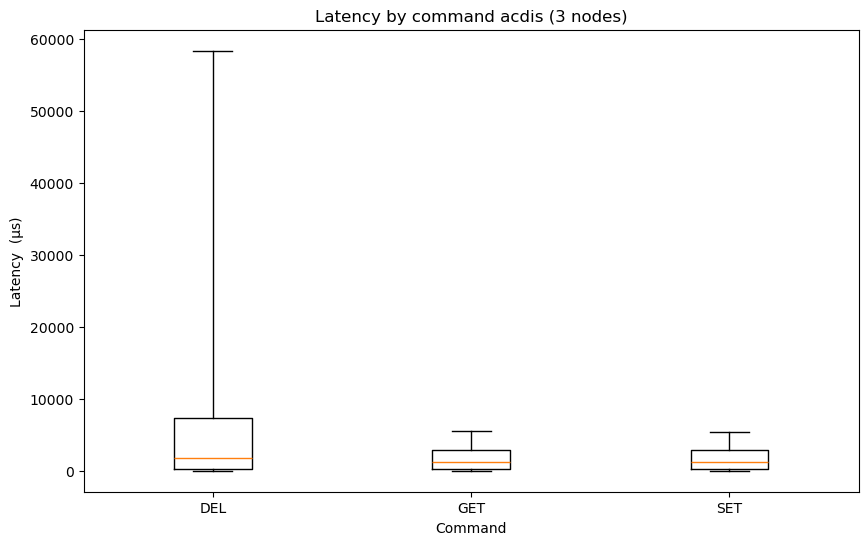

210    2465
211    2382
212    2393
213    2300
214    2088
215    2076
216    2032
217    1893
218    1927
219    1739
220    1799
221    1696
222    1717
223    1599
224    1485
225    1532
226    1487
227    1470
228    1349
229    1312
230    1326
231    1274
232    1150
233    1202
234    1211
235    1123
236    1097
237    1095
238    1080
240    1050
Name: count, dtype: int64

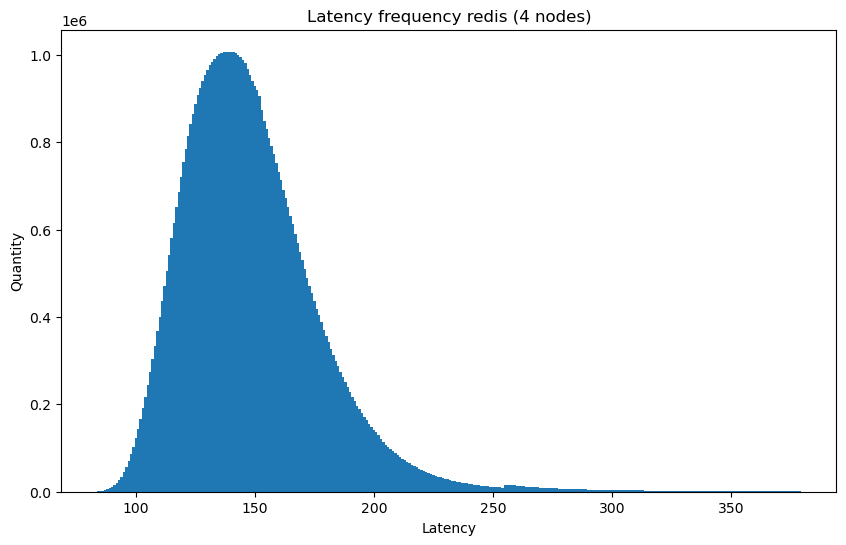

redis DEL: 145  μs
redis GET: 144  μs
redis SET: 150  μs


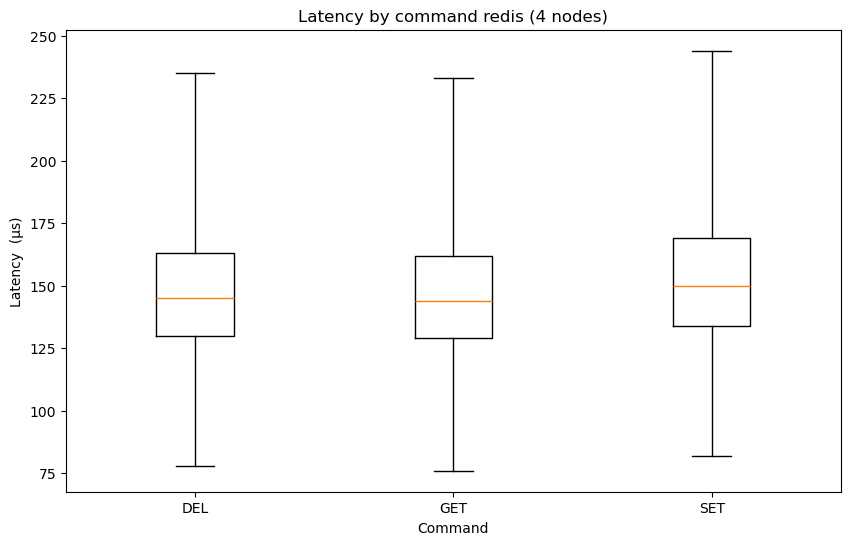

206    4575
207    4275
208    4275
209    3873
210    3832
211    3578
212    3426
213    3365
214    3116
215    3092
216    3092
217    2903
218    2704
219    2727
220    2620
221    2444
222    2424
223    2301
224    2321
225    2301
226    2205
227    2037
228    2068
229    1966
230    1951
231    1848
232    1843
233    1750
234    1686
235    1580
236    1614
237    1572
238    1556
239    1471
240    1494
241    1420
242    1391
243    1365
244    1270
245    1256
246    1209
247    1128
248    1207
249    1094
250    1145
251    1032
252    1010
253    1045
Name: count, dtype: int64

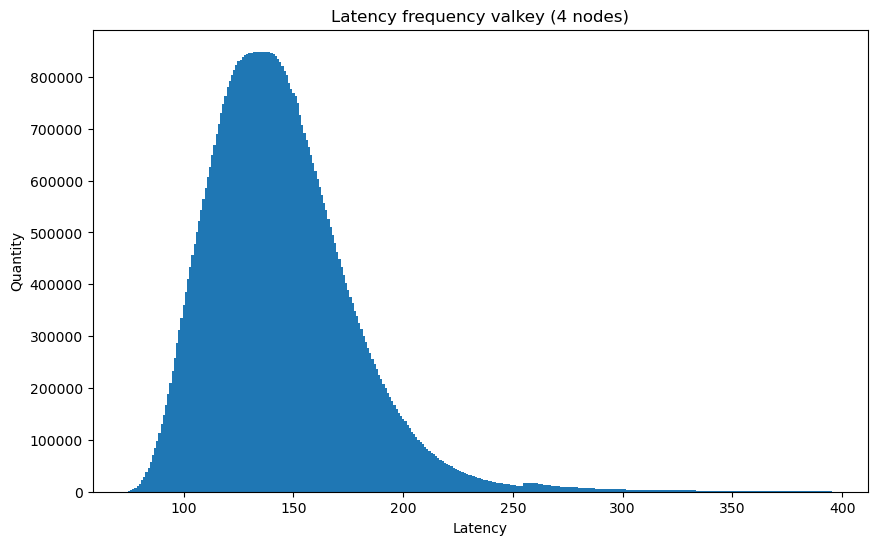

valkey DEL: 141  μs
valkey GET: 140  μs
valkey SET: 145  μs


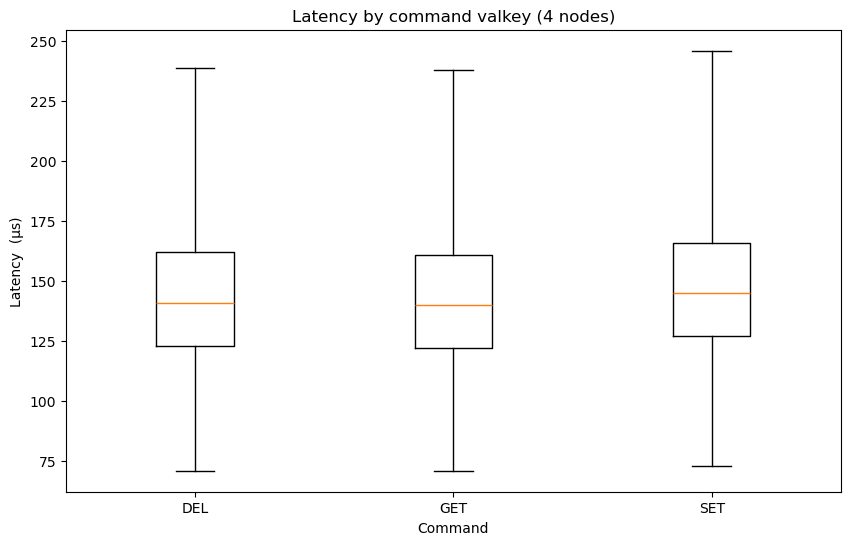

207    2606
208    2589
209    2524
210    2453
211    2250
212    2246
213    2200
214    2120
215    2098
216    1943
217    1965
218    1816
219    1788
220    1753
221    1711
222    1632
223    1582
224    1509
225    1421
226    1465
227    1381
228    1307
229    1272
230    1249
231    1231
232    1148
233    1137
234    1145
235    1098
236    1009
237    1014
Name: count, dtype: int64

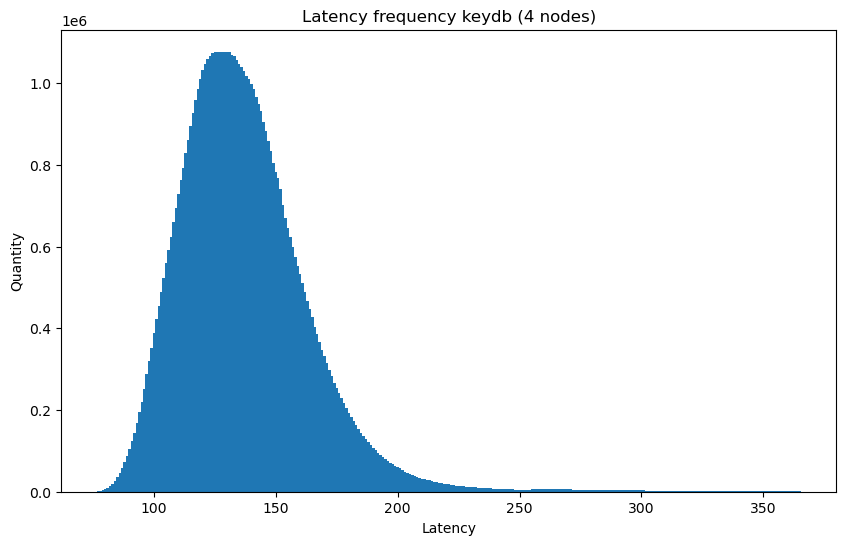

keydb DEL: 134  μs
keydb GET: 133  μs
keydb SET: 140  μs


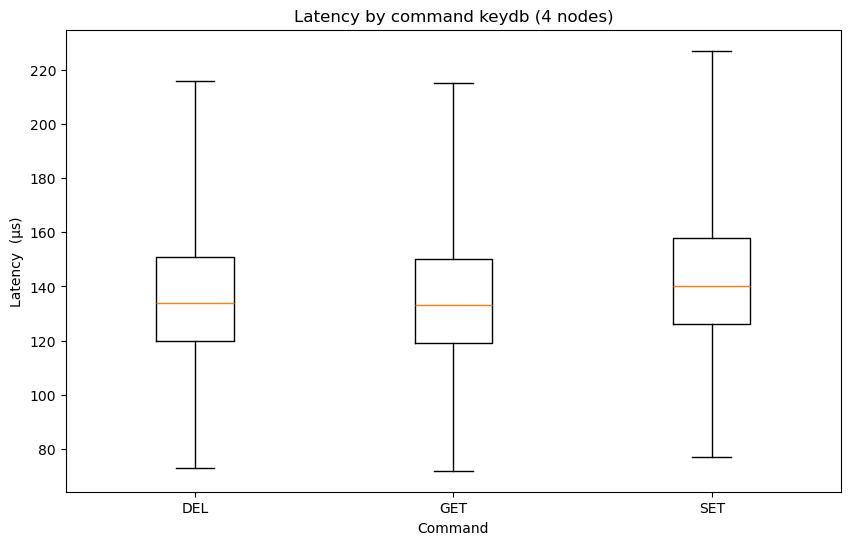

249     95
250    100
251     92
252    120
253    108
      ... 
309    224
310    237
311    226
312    240
313    234
Name: count, Length: 65, dtype: int64

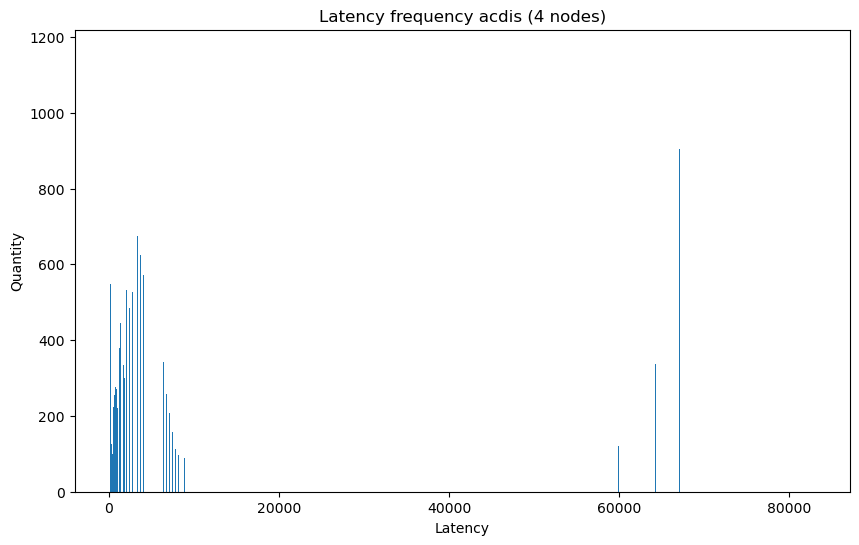

acdis DEL: 5311  μs
acdis GET: 2335  μs
acdis SET: 2351  μs


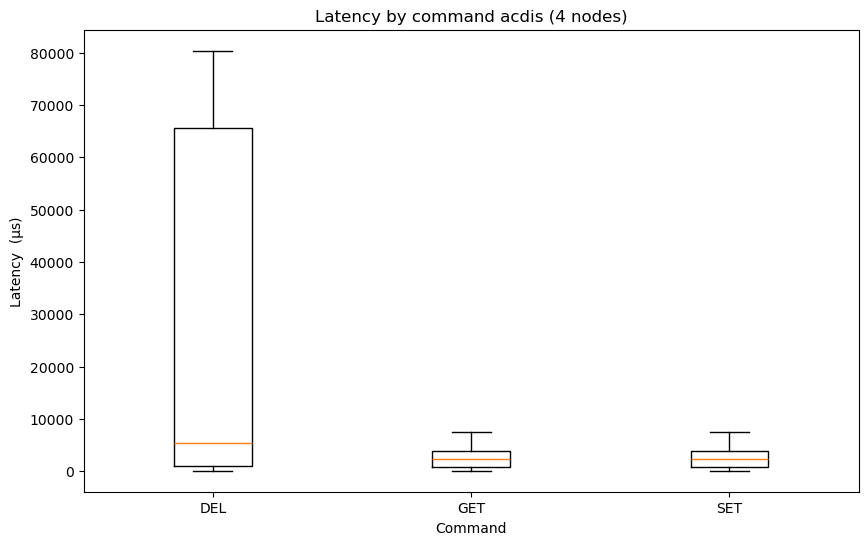

210    2158
211    2240
212    2062
213    1962
214    1950
215    1848
216    1870
217    1689
218    1596
219    1666
220    1592
221    1431
222    1474
223    1464
224    1337
225    1353
226    1277
227    1303
228    1193
229    1169
230    1138
231    1070
232    1043
233    1038
235    1050
Name: count, dtype: int64

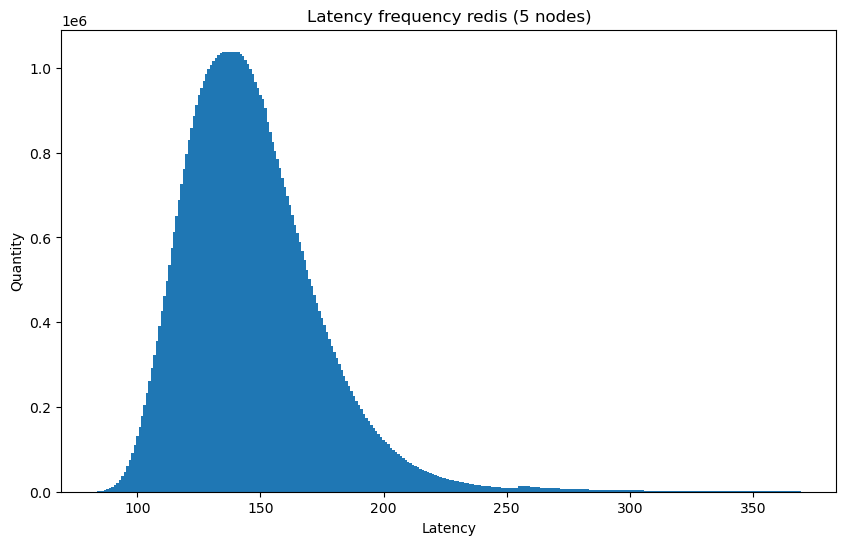

redis DEL: 144  μs
redis GET: 143  μs
redis SET: 148  μs


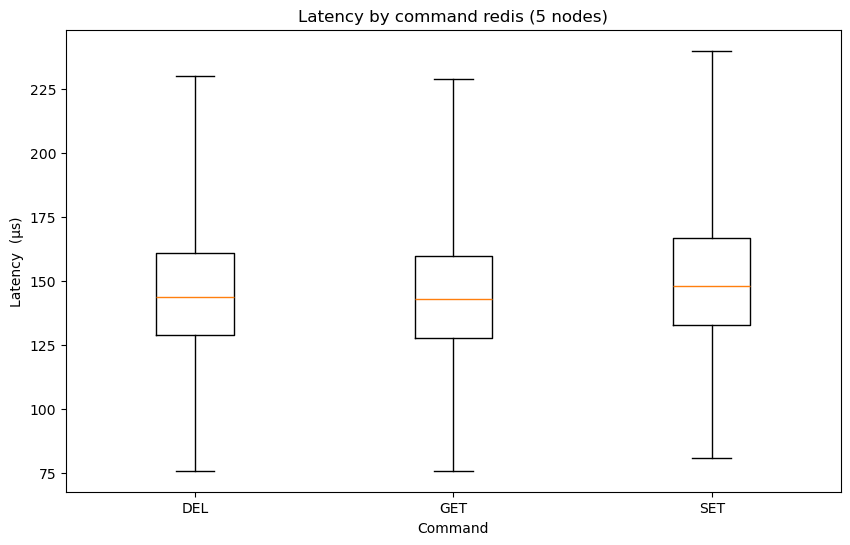

206    3044
207    2811
208    2776
209    2588
210    2427
211    2429
212    2294
213    2173
214    2024
215    2098
216    1988
217    1826
218    1715
219    1758
220    1681
221    1618
222    1508
223    1455
224    1408
225    1364
226    1284
227    1325
228    1250
229    1246
230    1140
231    1157
232    1161
233    1121
234    1078
Name: count, dtype: int64

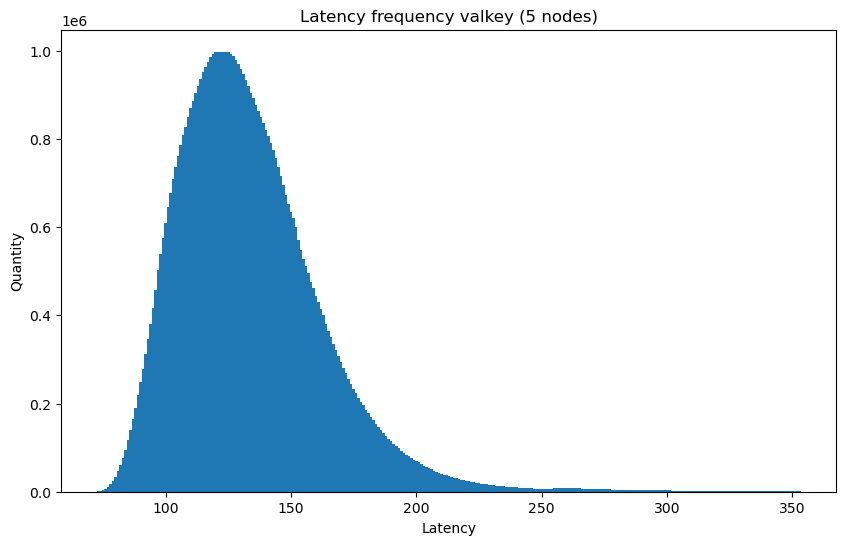

valkey DEL: 130  μs
valkey GET: 129  μs
valkey SET: 135  μs


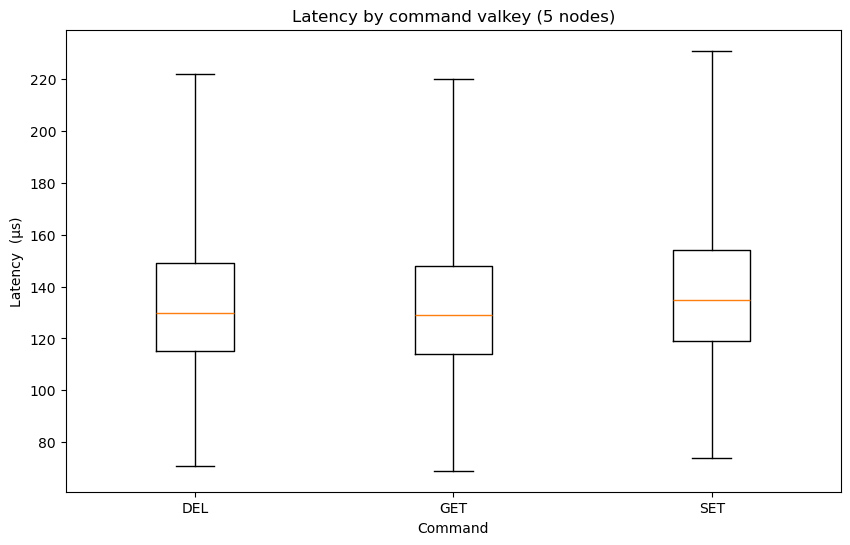

205    2551
206    2431
207    2400
208    2343
209    2126
210    2171
211    2086
212    1978
213    1991
214    1858
215    1792
216    1713
217    1697
218    1532
219    1582
220    1515
221    1423
222    1410
223    1364
224    1351
225    1230
226    1215
227    1269
228    1195
229    1145
230    1141
231    1044
232    1095
234    1022
Name: count, dtype: int64

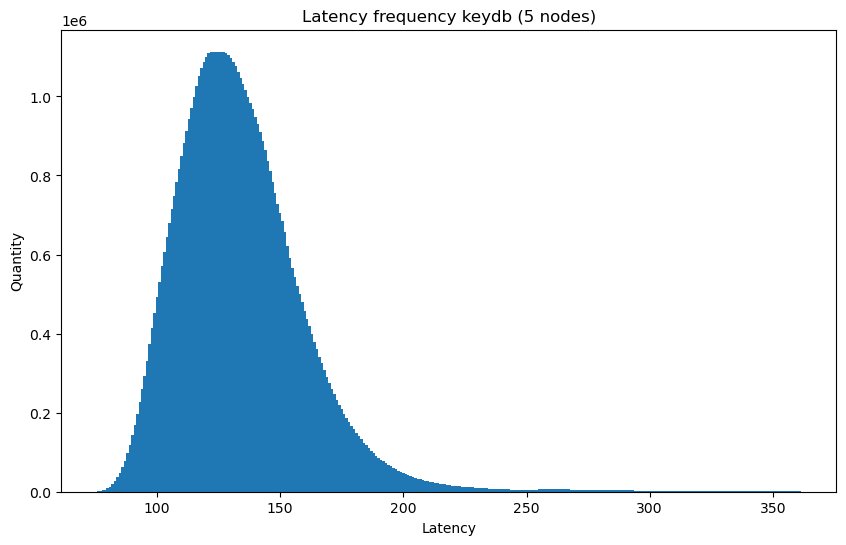

keydb DEL: 131  μs
keydb GET: 130  μs
keydb SET: 137  μs


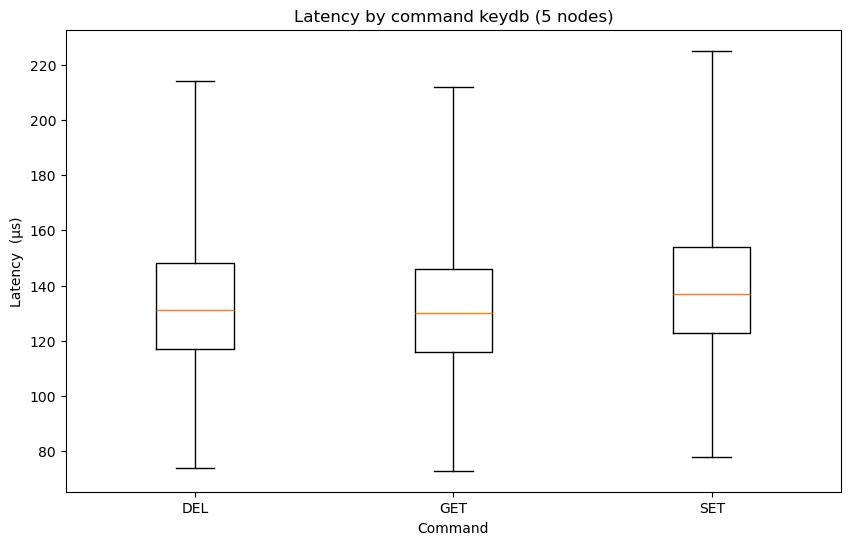

315     84
316     70
317     84
318     89
319     90
      ... 
375    140
376    147
377    125
378    136
379    134
Name: count, Length: 65, dtype: int64

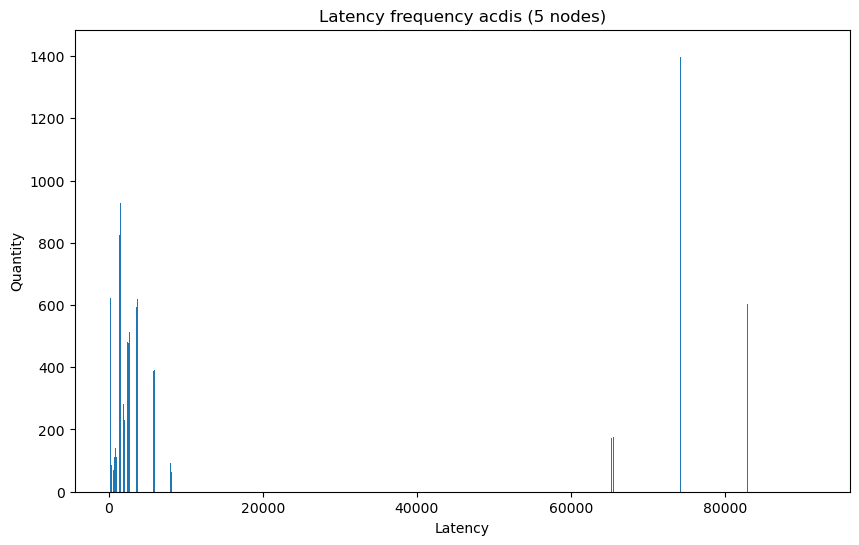

acdis DEL: 66559  μs
acdis GET: 2143  μs
acdis SET: 2175  μs


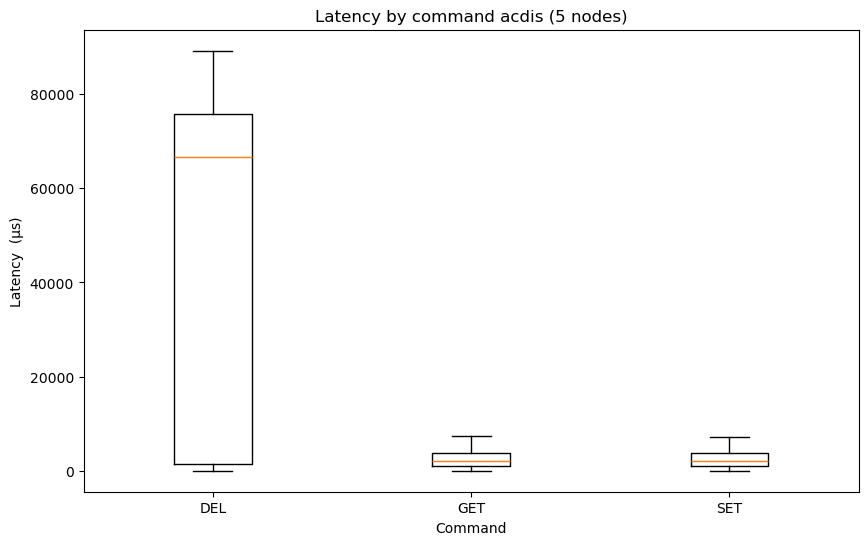

In [44]:
for cluster_size, folders in all_folders.items():
    # Dictionary of percentiles by service
    service_percentiles = {}
    node_percentiles = {}
    for folder in folders:
        service = folder.rstrip("/").split("/")[-1]
        service.rstrip(".csv")
        files = glob.glob(f"{folder}/*.csv")
    
        # List of dataframes for this service
        service_list = []
    
        for file in files:
            df = pd.read_csv(file, comment="#")
            df["service"] = service
            df["node"] = os.path.basename(file).rstrip(".csv")
    
            service_list.append(df)
    
        service_df = pd.concat(service_list, ignore_index=True)

        # Show barcharts for each latency frequency
        fig, ax = plt.subplots(figsize=(10, 6))

        threshold = 50 if service == "acdis" else 1000
        grouped_by_latency = service_df.groupby(["latency"])["count"].sum().reset_index()
        grouped_by_latency = grouped_by_latency[grouped_by_latency["count"] > threshold]
        display(grouped_by_latency["count"][200:265])
        
        plt.bar(grouped_by_latency["latency"], grouped_by_latency["count"], width=5)
        
        ax.set_title(f"Latency frequency {service} ({cluster_size} nodes)")
        ax.set_xlabel("Latency")
        ax.set_ylabel("Quantity")
        plt.savefig(f"images/{cluster_size}-nodes/{service}_latency_frequency.png")
        plt.show()
        plt.close()
    
        ### Analysis per project
        stats_list = []
        
        # Group by command to calculate stats for each box
        commands = service_df.groupby("cmd")
        latencies = []
        for name, cmd in commands:
                # Calculate stats without exploding
                cmd_percentiles = get_weighted_stats(cmd, val_col="latency", weight_col="count", label=name)
                print(f"{service} {cmd_percentiles["label"]}: {cmd_percentiles["med"]}  μs")
                #print(f"Median latency of {cmd} for {name}: {cmd_percentiles["med"]}")
                stats_list.append(cmd_percentiles)
                latencies.append(cmd_percentiles["med"])

        cmd_latencies[service].append(latencies)

        if service != "acdis":
            service_percentiles[service] = get_weighted_stats(service_df, val_col="latency", weight_col="count", label=service)
    
        # Plotting using bxp (Boxplot from pre-calculated stats)
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # bxp takes a list of dictionaries
        ax.bxp(stats_list, showfliers=False) 
        
        ax.set_title(f"Latency by command {service} ({cluster_size} nodes)")
        ax.set_xlabel("Command")
        ax.set_ylabel("Latency  (μs)")
        plt.savefig(f"images/{cluster_size}-nodes/{service}_latency_by_command.png")
        plt.show()
        plt.close()

    cluster_percentiles[cluster_size] = service_percentiles

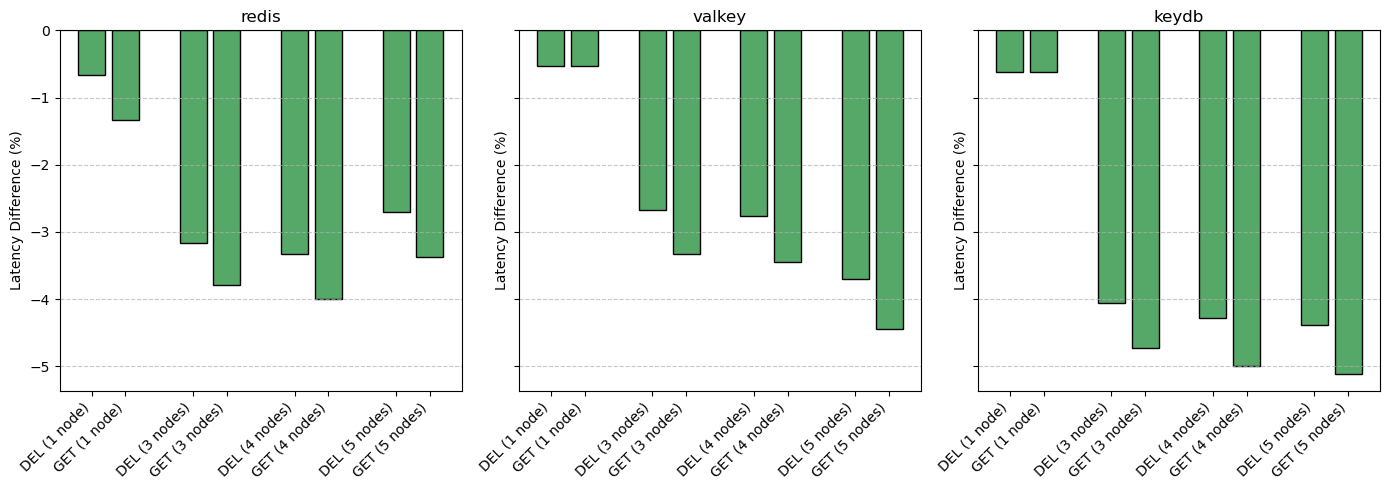

In [32]:
# Generate barcharts to show latency changes of GET, DEL relative to SET
# Turn absolute values to relative ones
relative = { service: [] for service in services }
for service, latencies in cmd_latencies.items():
    for group in latencies:
        # [DEL, GET, SET]
        baseline = group[-1]
        change_del = (group[0]-baseline)/baseline
        change_get = (group[1]-baseline)/baseline
        relative[service].append([change_del, change_get])

def flatten(xss):
    return [x for xs in xss for x in xs]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 5), sharey=True)
counter = 0;

for service, latencies in relative.items():
    if counter == 3:
        break # Skip acdis
    latency_diffs = flatten(latencies)
    latency_diffs = [x * 100 for x in latency_diffs]
    categories = [
        "DEL (1 node)",  "GET (1 node)",
        "DEL (3 nodes)", "GET (3 nodes)",
        "DEL (4 nodes)", "GET (4 nodes)",
        "DEL (5 nodes)", "GET (5 nodes)",
    ]
    
    # 2. Setup Figure
    ax = axes[counter]
    counter += 1

    # 2. Calculate custom X positions
    x_positions = []
    current_x = 0
    gap_size = 1.0  # Adjust this value to make the gap wider or narrower
    
    for i in range(len(categories)):
        x_positions.append(current_x)
        current_x += 1 # Standard width for the next bar
        
        # Add an extra gap after every 2nd bar
        if (i + 1) % 2 == 0:
            current_x += gap_size

    # 3. Dynamic Coloring (Green for negative/faster, Red for positive/slower)
    green = '#55a868'
    red = '#c44e52'
    colors = [red if val >= 0 else green for val in latency_diffs]
    
    # 4. Plot the bars
    bars = ax.bar(x_positions, latency_diffs, color=colors, edgecolor='black', width=0.8)
    
    # 5. Add a distinct zero-line
    ax.axhline(0, color='black', linewidth=1.5)
    # Attach the text labels to the exact coordinates we calculated
    ax.set_xticks(x_positions)
    ax.set_xticklabels(categories, rotation=45, ha='right')
    
    # 6. Labels and Styling
    ax.set_ylabel('Latency Difference (%)')
    ax.set_title(f"{service}")
    ax.grid(axis='y', linestyle='--', alpha=0.7) # Subtle background grid
    
    # 7. Output
    plt.tight_layout()
    
    # If your window manager doesn't play nicely with matplotlib's default GUI popups, 
    # saving directly to a file is often cleaner:
    plt.savefig('images/cmd_latency_variance.png', dpi=300) 
    
    # Or display it interactively
plt.show()

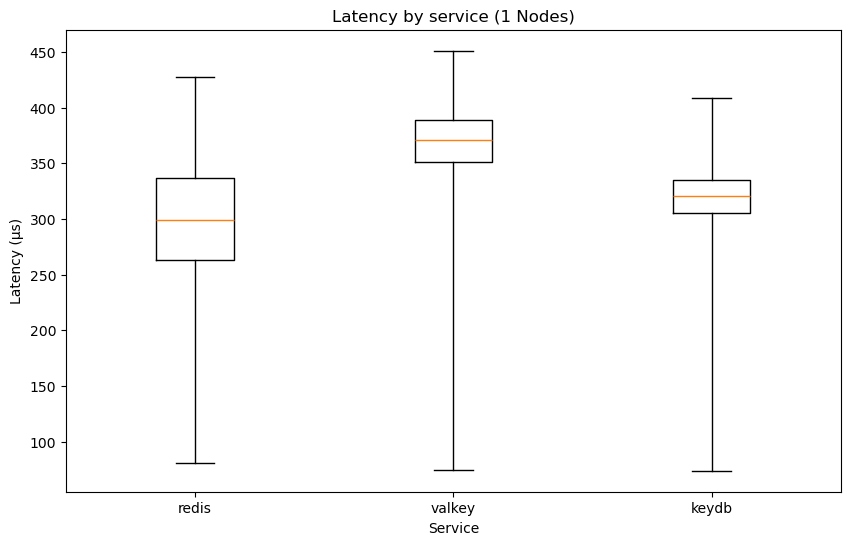

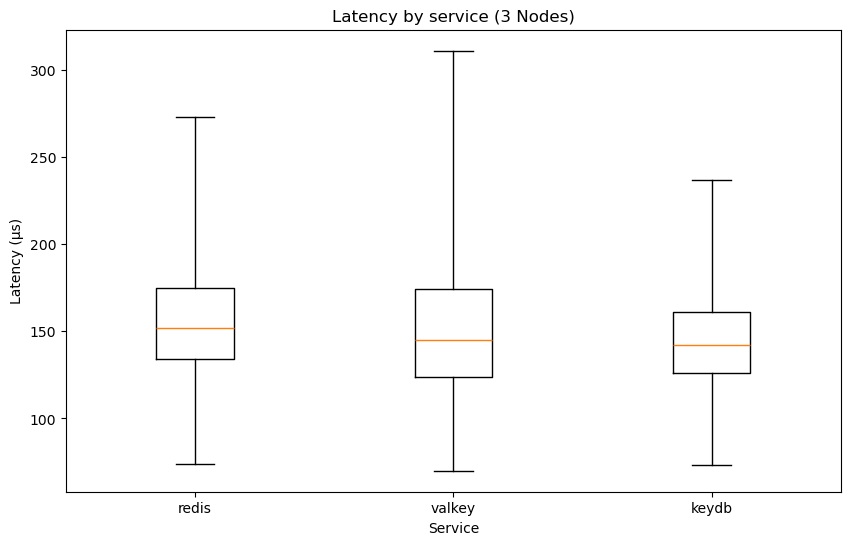

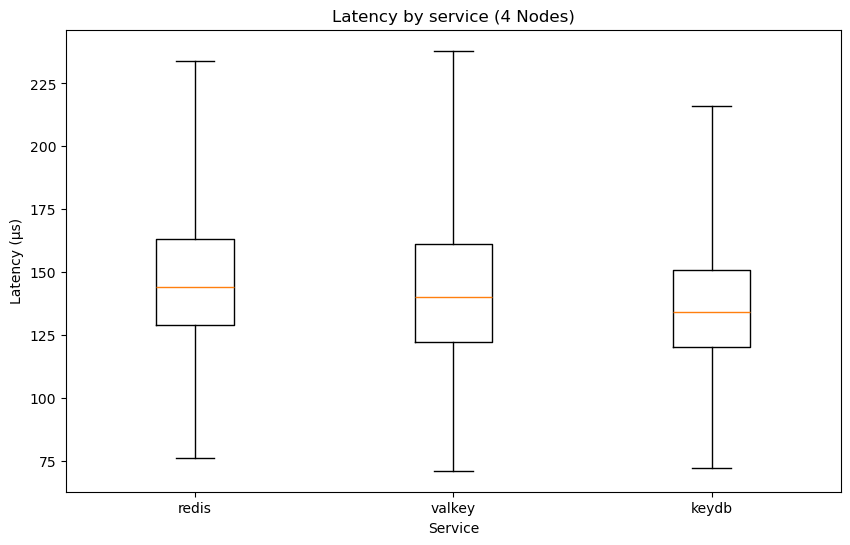

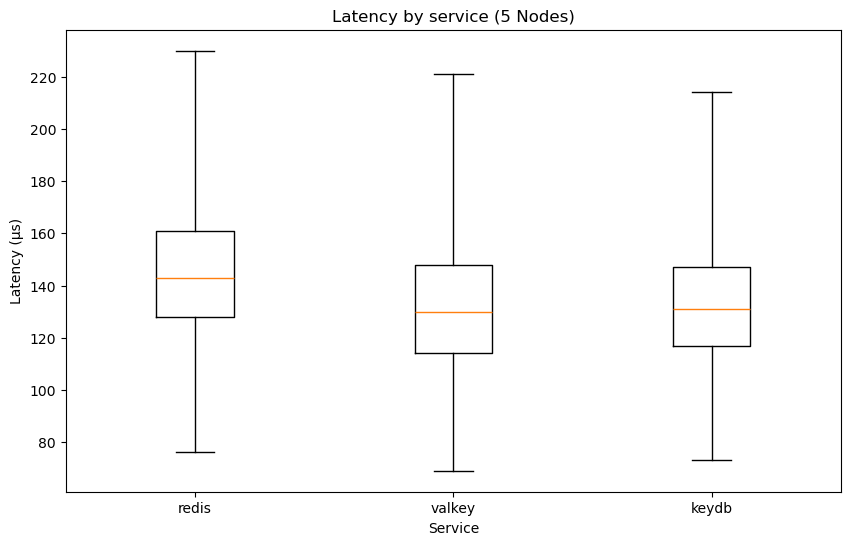

In [20]:
for size, percentiles in cluster_percentiles.items():
    # Plotting using bxp (Boxplot from pre-calculated stats)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # bxp takes a list of dictionaries
    ax.bxp(percentiles.values(), showfliers=False) 
    
    ax.set_title(f"Latency by service ({size} Nodes)")
    ax.set_xlabel("Service")
    ax.set_ylabel("Latency (μs)")
    plt.show()
    plt.close()

In [21]:
# Graph latency for each service with different cluster sizes
same_service_different_size = { service: {} for service in services}
for size, service_dict in cluster_percentiles.items():
    for service, percentiles in service_dict.items():
        percentiles["label"] = size
        same_service_different_size[service][size] = percentiles

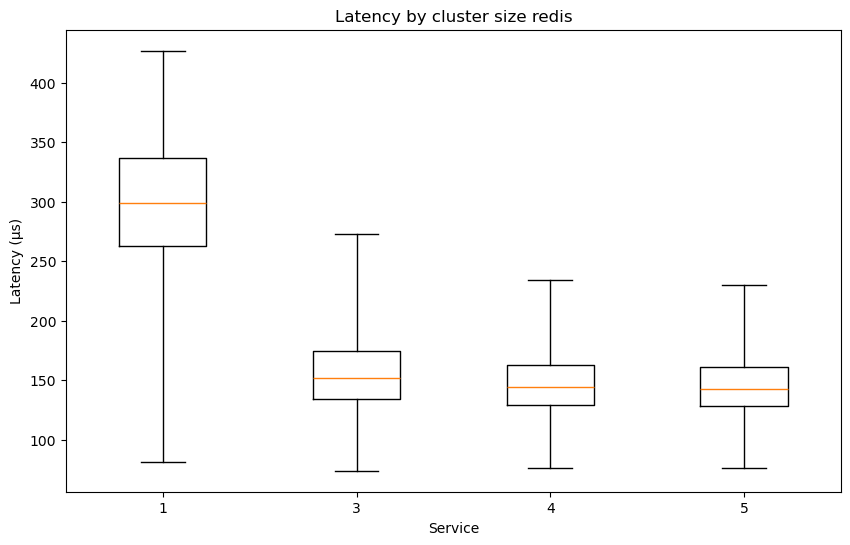

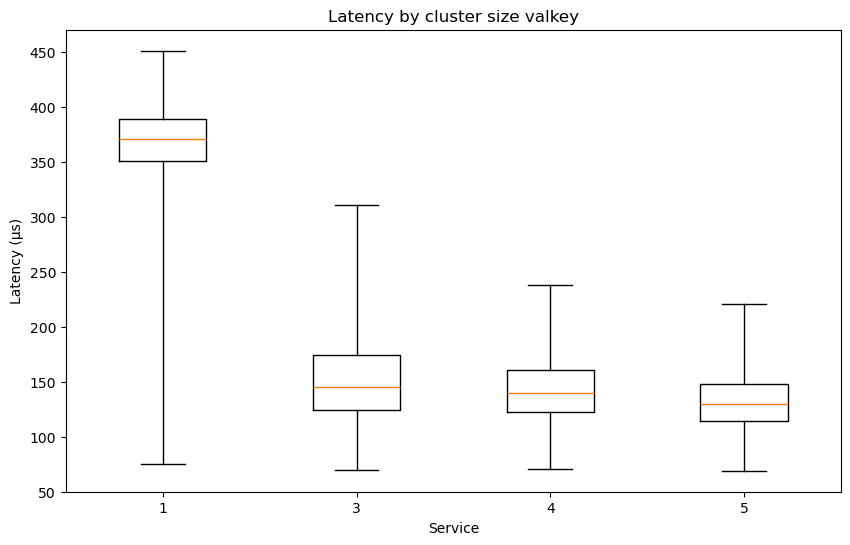

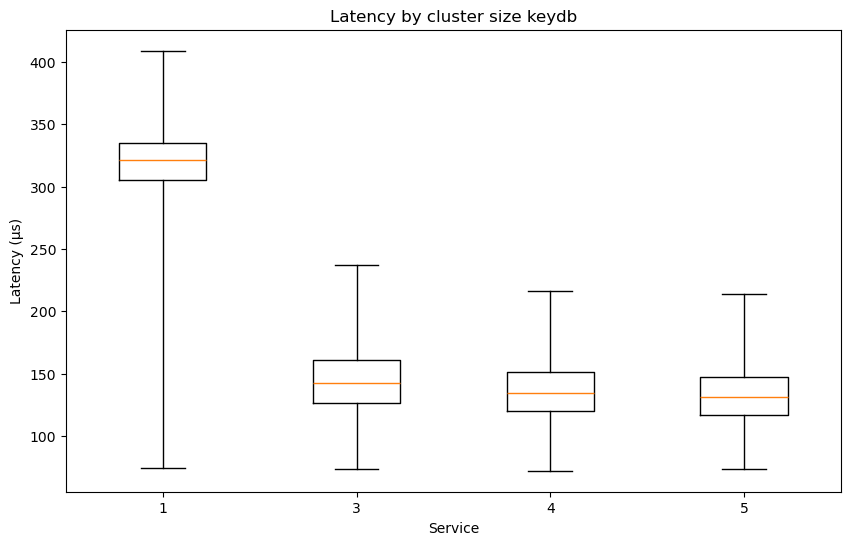

In [23]:
for service, percentiles in same_service_different_size.items():
    if service == "acdis":
        continue
    # Plotting using bxp (Boxplot from pre-calculated stats)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # bxp takes a list of dictionaries
    ax.bxp(percentiles.values(), showfliers=False) 
    
    ax.set_title(f"Latency by cluster size {service}")
    ax.set_xlabel("Service")
    ax.set_ylabel("Latency (μs)")
    plt.savefig(f"images/{service}_latency_by_cluster_size.png")
    plt.show()
    plt.close()

SUT       keydb  redis  valkey
Category                      
One          74     81      75
Three        73     74      70
Four         72     76      71
Five         73     76      69


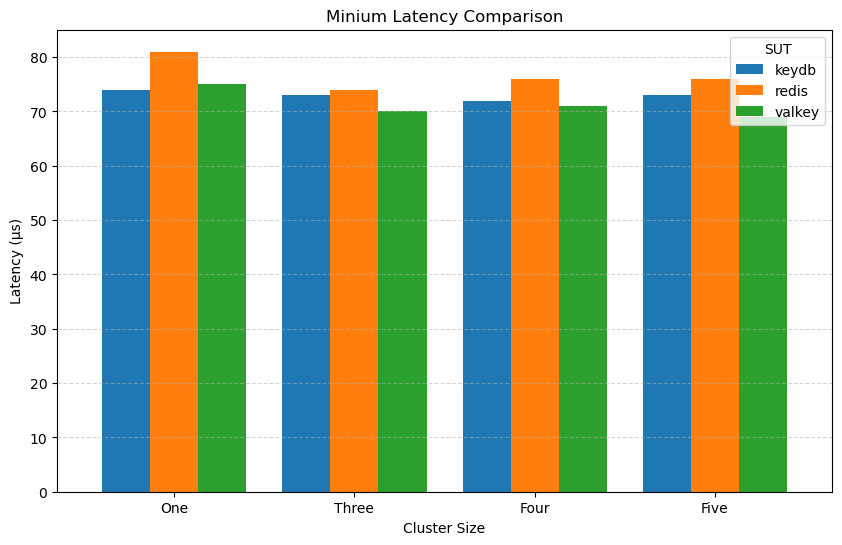

SUT       keydb  redis  valkey
Category                      
One         321    299     371
Three       142    152     145
Four        134    144     140
Five        131    143     130


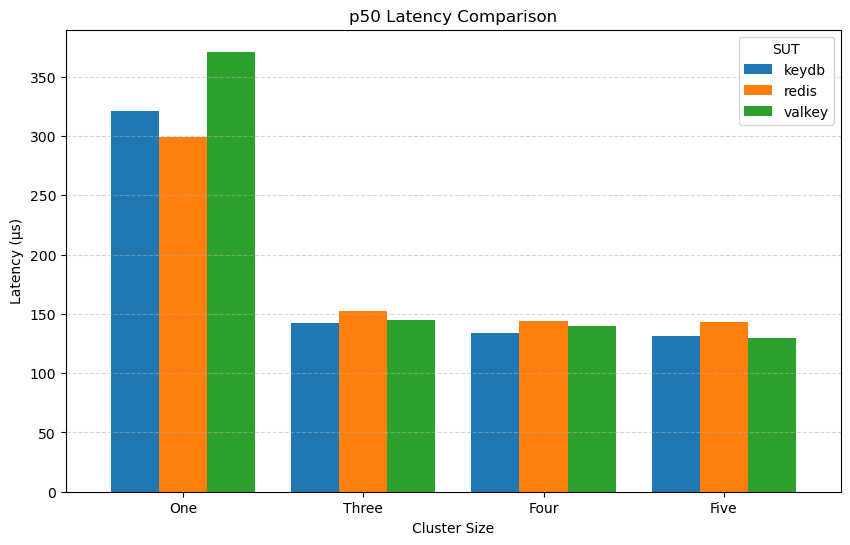

SUT       keydb  redis  valkey
Category                      
One         409    427     451
Three       237    273     311
Four        216    234     238
Five        214    230     221


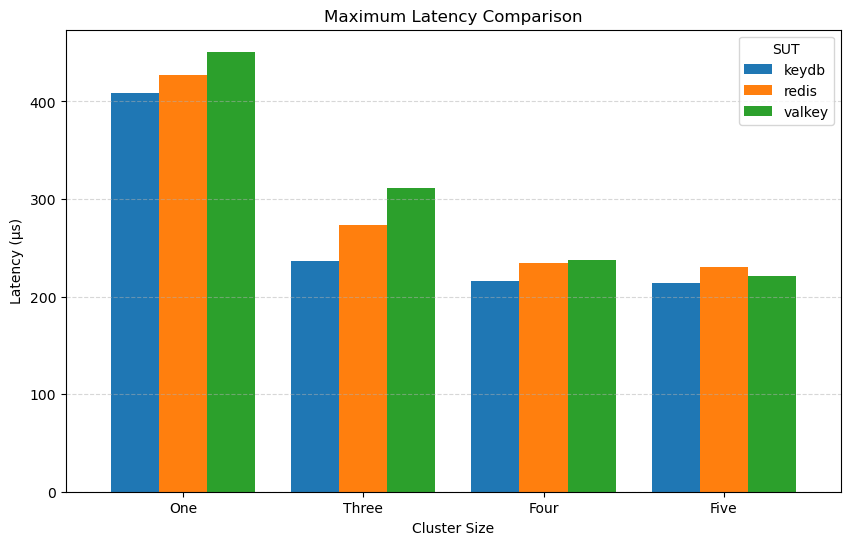

In [26]:
def overview(name, index):
    records = []
    for sut, sizes in same_service_different_size.items():
        if sut != "acdis":
            for size, stats in sizes.items():
                records.append({
                    'SUT': sut, 
                    'Category': size, 
                    name: stats[index]
                })
    
    df = pd.DataFrame(records)
    
    df_pivot = df.pivot(index='Category', columns='SUT', values=name)
    
    # Rename index to words
    df_pivot.index = df_pivot.index.map({1: 'One', 3: 'Three', 4: 'Four', 5: 'Five'})
    print(df_pivot)
    
    ax = df_pivot.plot(kind='bar', figsize=(10, 6), width=0.8)
    
    plt.title(f"{name} Latency Comparison")
    plt.ylabel('Latency (μs)')
    plt.xlabel('Cluster Size')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(title='SUT')
    plt.savefig(f"images/barchart_{name}_latency.png")
    plt.show()

overview("Minium", "whislo")
overview("p50", "med")
overview("Maximum", "whishi")

In [25]:
def plot_memory(title, path):
    df = pd.read_csv(path, comment="#")
    
    # Drop last entry because it contained 'undefined'
    df = df.head(df.shape[0] -1)
    df = df[5:]
    df = df.drop(columns=['TimeSeries ID'], axis=1)
    # Treat all values as numbers
    df = df.astype(float)
    df = df.rename(columns={
        "tex-chart-0-0": "Node 1",
        "tex-chart-0-1": "Node 2",
        "tex-chart-0-2": "Node 3"
    })
    
    # Extend data so it looks better plotted ###
    last_row = df.iloc[-1]
    last_index = df.index.max()
    new_last = 30
    new_rows = []
    np.random.seed(42)
    for i in range(new_last - last_index):
        jitter = np.random.normal(0, 0.1, size=len(last_row))
        new_row = last_row + jitter
        new_rows.append(new_row)
    
    # Fix index
    start_index = df.index.max() + 1
    new_index = range(start_index, new_last+1)
    df_extended = pd.concat([df, pd.DataFrame(new_rows, index=new_index)])
    
    
    # 1. Find the column and row index of the highest value
    max_col = df_extended.max().idxmax()
    max_row = df_extended[max_col].idxmax()
    max_val = df_extended.loc[max_row, max_col] # Actual value
    print(f"Placing marker at {max_val}!")
    
    
    #### Plot ####
    plt.figure(figsize=(10, 6))
    
    # Plot Lines
    for column in df_extended.columns:
        plt.plot(df_extended.index, df_extended[column], label=column)
    
    # Plot Marker
    plt.scatter(max_row, max_val, color='red', marker='o', s=50, zorder=5)
    plt.annotate(f'OOM Killed', (max_row, max_val), 
                 xytext=(5, 5), textcoords='offset points', color='red')
    
    plt.title(f'Acdis Memory Usage ({title})')
    plt.xlabel('Time')
    plt.xticks([])
    plt.ylabel('Memory Usage (%)')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'images/GCP_Memory_{title}.png')

Placing marker at 95.58662862033447!
Placing marker at 94.7026098570705!
Placing marker at 90.75074320839799!


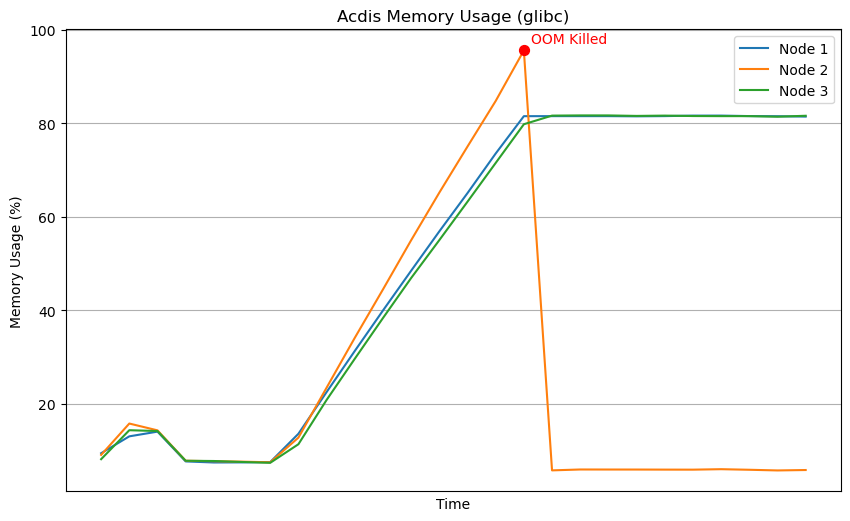

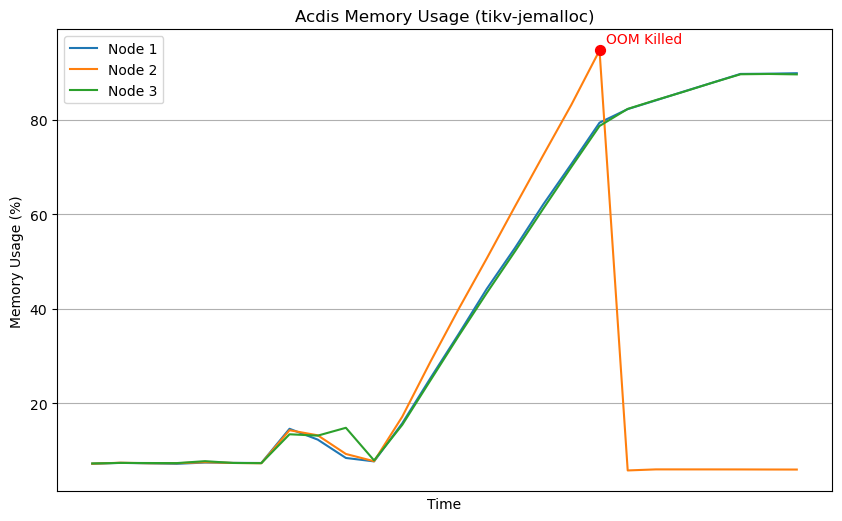

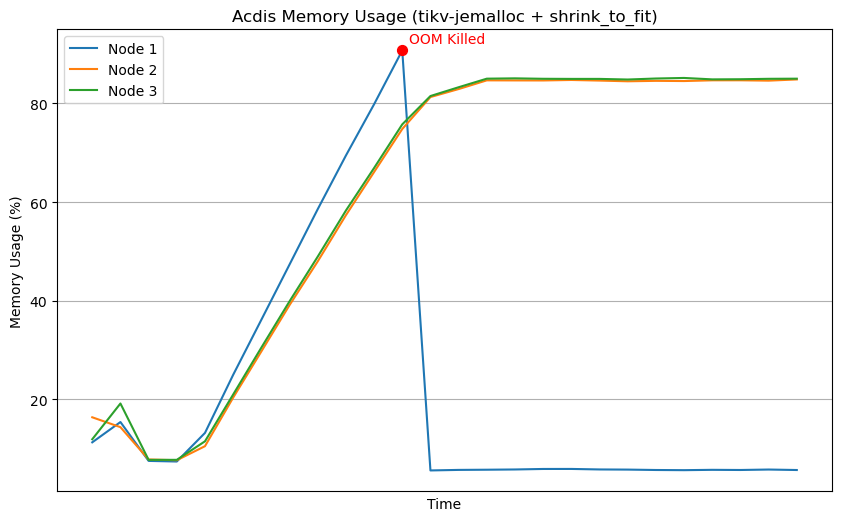

In [13]:
plot_memory("glibc", "gcp_memory/glibc.csv")
plot_memory("tikv-jemalloc", "gcp_memory/tikv-jemalloc.csv")
plot_memory("tikv-jemalloc + shrink_to_fit", "gcp_memory/tikv-jemalloc-shrink.csv")